<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/main/notebooks/01_working_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Bootstrap: make paths work in Colab ---
import os, pathlib, subprocess

REPO_URL = "https://github.com/nyee88/tvam_resin_mini.git"  # your repo URL
REPO_DIR = "tvam_resin_mini"

if not pathlib.Path(REPO_DIR).exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

os.chdir(REPO_DIR)
print("CWD:", os.getcwd())
print("CSV exists?", pathlib.Path("data/ec_dp_405nm.csv").exists())


CWD: /content/tvam_resin_mini
CSV exists? True


,resin_or_source,Ec_mJ_cm2,Dp_um,wavelength_nm,notes
0,ExampleResin_A,6.5,120,405,vendor or paper link
1,ExampleResin_B,4.8,85,405,vendor or paper link
2,ExampleResin_C,10.2,200,405,vendor or paper link
3,Fast_Clear_Gen1,4.0,70,405,low Ec but shallow Dp
4,Fast_Clear_Gen2,3.2,90,405,improved clear formulation
5,Tough_Amber,8.0,150,405,tough resin deeper penetration
6,Black_HiRes,7.5,60,405,pigmented low Dp
7,Dental_Model,5.5,110,405,balanced Ec/Dp
8,Castable_WaxLike,9.0,80,405,high Ec more picky
9,Ultra_Clear_Deep,6.0,220,405,depth-optimized


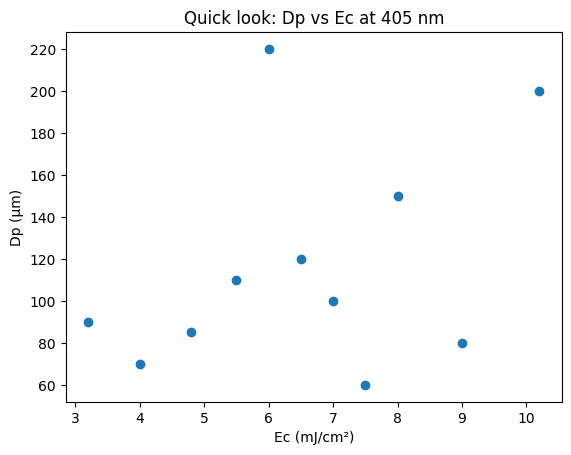

,resin_or_source,Ec_mJ_cm2,Dp_um,E_needed_mJcm2_for_100um
0,ExampleResin_A,6.5,120,14.956343
1,ExampleResin_B,4.8,85,15.565960
2,ExampleResin_C,10.2,200,16.816957
3,Fast_Clear_Gen1,4.0,70,16.690936
4,Fast_Clear_Gen2,3.2,90,9.720742
5,Tough_Amber,8.0,150,15.581872
6,Black_HiRes,7.5,60,39.708675
7,Dental_Model,5.5,110,13.651358
8,Castable_WaxLike,9.0,80,31.413087
9,Ultra_Clear_Deep,6.0,220,9.452743


In [2]:
# --- Install minimal deps (fast) ---
!pip -q install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1) Load your tiny Ec/Dp table ---
csv_path = "data/ec_dp_405nm.csv"  # when saved back to GitHub, this relative path will work
df = pd.read_csv(csv_path, comment='#')

# Basic sanity checks
required = ["resin_or_source", "Ec_mJ_cm2", "Dp_um", "wavelength_nm"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert (df["wavelength_nm"] == 405).all(), "Keep wavelength at 405 nm for now."

display(df)

# --- 2) Quick plot: Dp vs Ec (both matter for exposure) ---
plt.figure()
plt.scatter(df["Ec_mJ_cm2"], df["Dp_um"])
plt.xlabel("Ec (mJ/cm²)")
plt.ylabel("Dp (µm)")
plt.title("Quick look: Dp vs Ec at 405 nm")
plt.show()

# --- 3) Tiny demo: dose needed for a target cured depth ---
# Jacobs working-curve: Cd = Dp * ln(E / Ec)  -> E = Ec * exp(Cd/Dp)
target_Cd_um = 100  # e.g., aim to fully cure ~100 µm
df["E_needed_mJcm2_for_100um"] = df.apply(
    lambda r: r["Ec_mJ_cm2"] * (2.718281828 ** (target_Cd_um / r["Dp_um"])),
    axis=1
)
display(df[["resin_or_source", "Ec_mJ_cm2", "Dp_um", "E_needed_mJcm2_for_100um"]])


In [3]:
import numpy as np

for L_um in [50, 100, 150]:
    E_needed = df["Ec_mJ_cm2"] * np.exp(L_um / df["Dp_um"])
    print(f"\nLayer L = {L_um} µm  (lower is better)")
    display(df.assign(E_for_L=E_needed)[["resin_or_source","E_for_L"]]
              .sort_values("E_for_L"))



Layer L = 50 µm  (lower is better)


,resin_or_source,E_for_L
4,Fast_Clear_Gen2,5.577309
9,Ultra_Clear_Deep,7.531033
3,Fast_Clear_Gen1,8.170908
1,ExampleResin_B,8.643877
7,Dental_Model,8.665014
0,ExampleResin_A,9.859829
5,Tough_Amber,11.164899
10,Budget_Generic,11.541049
2,ExampleResin_C,13.097059
8,Castable_WaxLike,16.814214



Layer L = 100 µm  (lower is better)


,resin_or_source,E_for_L
9,Ultra_Clear_Deep,9.452743
4,Fast_Clear_Gen2,9.720742
7,Dental_Model,13.651358
0,ExampleResin_A,14.956343
1,ExampleResin_B,15.565960
5,Tough_Amber,15.581872
3,Fast_Clear_Gen1,16.690936
2,ExampleResin_C,16.816957
10,Budget_Generic,19.027973
8,Castable_WaxLike,31.413087



Layer L = 150 µm  (lower is better)


,resin_or_source,E_for_L
9,Ultra_Clear_Deep,11.864819
4,Fast_Clear_Gen2,16.942368
7,Dental_Model,21.507129
2,ExampleResin_C,21.593400
5,Tough_Amber,21.746255
0,ExampleResin_A,22.687229
1,ExampleResin_B,28.031302
10,Budget_Generic,31.371823
3,Fast_Clear_Gen1,34.095026
8,Castable_WaxLike,58.687372


In [4]:
# --- Method A: Learn alpha (two points per resin) and APPLY IT GLOBALLY ---
#
import numpy as np
import pandas as pd

# Assumes you already have df with columns: resin_or_source, Ec_mJ_cm2, Dp_um
# df.head()

# ==== 1) Config: job + temps ====
T0_C       = 23.0   # reference temperature for the vendor Ec in df (assume 23°C)
T_today    = 25.0   # <-- set today's measured temperature
I_mWcm2    = 5.0    # irradiance at resin plane (mW/cm²)
L_um       = 100    # target cured depth (≈ layer thickness)
safety     = 1.15   # small cushion

# ==== 2) Minimal calibration data: Ec at two temps per resin ====
# Replace these with your measured (or synthetic) pairs.
ec_pairs = pd.DataFrame({
    "resin_or_source": ["ExampleResin_A","ExampleResin_B","ExampleResin_C"],
    "T1_C":            [22.0, 22.0, 22.0],
    "Ec1_mJcm2":       [6.8,  5.0, 10.5],   # Ec measured at T1
    "T2_C":            [26.0, 26.0, 26.0],
    "Ec2_mJcm2":       [6.4,  4.7, 10.0],   # Ec measured at T2
})

# ==== 3) Per-resin alpha from two points: alpha = d(ln Ec)/dT ====
dT = ec_pairs["T2_C"] - ec_pairs["T1_C"]
ec_pairs["alpha_per_C"] = (np.log(ec_pairs["Ec2_mJcm2"]) - np.log(ec_pairs["Ec1_mJcm2"])) / dT

# (Optional sanity) show per-resin α
display(ec_pairs[["resin_or_source","alpha_per_C"]])

# ==== 4) Choose a global alpha (simple mean of per-resin) ====
alpha_global = ec_pairs["alpha_per_C"].mean()
print(f"Global alpha (mean): {alpha_global:.4f} per °C  (~{100*alpha_global:.1f}%/°C)")

# ==== 5) Temperature-adjust Ec to today's T and compute dose/time ====
# Assume df['Ec_mJ_cm2'] is defined at T0_C. Adjust to today's T:
Ec_T = df["Ec_mJ_cm2"] * np.exp(alpha_global * (T_today - T0_C))

# Dose for target layer with safety, then time = dose / I
E_star_T = safety * Ec_T * np.exp(L_um / df["Dp_um"])
t_star_T = E_star_T / I_mWcm2

result = df.assign(
    Ec_at_T=Ec_T,
    E_star_mJcm2=E_star_T,
    t_star_s=t_star_T
)[["resin_or_source","Ec_at_T","E_star_mJcm2","t_star_s"]].sort_values("t_star_s")

display(result)

# alpha is the percent Ec decreases by degree centigrade. we can calculate a universal alpha by averaging all, for unknown resins.
# E star is simply the energy required to cure 100 um depth (arbitrary)
# t_star is  E_star/5_mWcm^2 (we arbitrarily picked the irradiance)



,resin_or_source,alpha_per_C
0,ExampleResin_A,-0.015156
1,ExampleResin_B,-0.015469
2,ExampleResin_C,-0.012198


Global alpha (mean): -0.0143 per °C  (~-1.4%/°C)


,resin_or_source,Ec_at_T,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,10.564703,2.112941
4,Fast_Clear_Gen2,3.109937,10.864227,2.172845
7,Dental_Model,5.345204,15.257216,3.051443
0,ExampleResin_A,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,17.397040,3.479408
5,Tough_Amber,7.774842,17.414824,3.482965
3,Fast_Clear_Gen1,3.887421,18.654350,3.730870
2,ExampleResin_C,9.912924,18.795196,3.759039
10,Budget_Generic,6.802987,21.266301,4.253260
8,Castable_WaxLike,8.746698,35.108321,7.021664


In [5]:
import numpy as np
import pandas as pd

def plan_exposures(
    df_resins,
    L_um=100,
    I_mWcm2=5.0,
    safety=1.15,
    T_today=25.0,
    T_ref=23.0,
    alpha_global=None,
    use_temp_correction=True,
):
    """
    Tiny helper that wraps what you're already doing:

    Inputs:
      - df_resins: DataFrame with Ec_mJ_cm2, Dp_um, resin_or_source
      - L_um:      target cured depth / layer thickness (µm)
      - I_mWcm2:   irradiance (mW/cm²)
      - safety:    multiplier on top of Jacobs
      - T_today:   actual temperature
      - T_ref:     reference temp for Ec values
      - alpha_global: d(ln Ec)/dT. If None, try ec_pairs; else fallback.
      - use_temp_correction: toggle temperature adjustment on/off.

    Output:
      - DataFrame with Ec_effective, E*, t*, sorted fastest → slowest.
    """
    df = df_resins.copy()

    # 1) Decide alpha_global
    if use_temp_correction:
        if alpha_global is None:
            # If you already computed ec_pairs above, reuse it.
            if "ec_pairs" in globals() and "alpha_per_C" in ec_pairs.columns:
                alpha_global = ec_pairs["alpha_per_C"].mean()
            else:
                # fallback: the ~-1.4%/°C you just got
                alpha_global = -0.0143

        # 2) Temperature-adjusted Ec
        Ec_effective = df["Ec_mJ_cm2"] * np.exp(alpha_global * (T_today - T_ref))
    else:
        Ec_effective = df["Ec_mJ_cm2"]

    # 3) Jacobs + safety: E* and t*
    E_star = safety * Ec_effective * np.exp(L_um / df["Dp_um"])
    t_star = E_star / I_mWcm2

    out = df.assign(
        Ec_effective_mJ_cm2=Ec_effective,
        E_star_mJcm2=E_star,
        t_star_s=t_star
    ).sort_values("t_star_s")

    return out[[
        "resin_or_source",
        "Ec_effective_mJ_cm2",
        "Dp_um",
        "Ec_effective_mJ_cm2",
        "E_star_mJcm2",
        "t_star_s"
    ]]


In [6]:
# test with exactly the same values as before - sanity check. Should output the same table as before.

# Quick test of our new planner function: given a planned job (layer thickness, light intensity, safety factor, temperature),
# it uses each resin’s Ec and Dp to calculate a recommended dose (E*) and exposure time (t*), then shows a table of all resins
# ranked by speed so we can sanity-check that the numbers and ordering look sensible before using it for synthetic data/ML.


plans_100um = plan_exposures(df, L_um=100, I_mWcm2=5.0, safety=1.15,
                             T_today=25.0, T_ref=23.0, use_temp_correction=True)
display(plans_100um)


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,220,5.831132,10.564703,2.112941
4,Fast_Clear_Gen2,3.109937,90,3.109937,10.864227,2.172845
7,Dental_Model,5.345204,110,5.345204,15.257216,3.051443
0,ExampleResin_A,6.317059,120,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,85,4.664905,17.397040,3.479408
5,Tough_Amber,7.774842,150,7.774842,17.414824,3.482965
3,Fast_Clear_Gen1,3.887421,70,3.887421,18.654350,3.730870
2,ExampleResin_C,9.912924,200,9.912924,18.795196,3.759039
10,Budget_Generic,6.802987,100,6.802987,21.266301,4.253260
8,Castable_WaxLike,8.746698,80,8.746698,35.108321,7.021664


In [7]:
for L in [50, 100, 150]:
    print(f"\n=== Target layer: {L} µm ===")
    display(plan_exposures(df, L_um=L, I_mWcm2=5.0, safety=1.15,
                           T_today=25.0, T_ref=23.0).head(5))

    # Plan three example jobs (50, 100, 150 µm): for each thickness we call the same planner,
# overriding L_um with that value to see how recommended E* and t* change across layer heights.




=== Target layer: 50 µm ===


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
4,Fast_Clear_Gen2,3.109937,90,3.109937,6.233388,1.246678
9,Ultra_Clear_Deep,5.831132,220,5.831132,8.416935,1.683387
3,Fast_Clear_Gen1,3.887421,70,3.887421,9.132081,1.826416
1,ExampleResin_B,4.664905,85,4.664905,9.660687,1.932137
7,Dental_Model,5.345204,110,5.345204,9.684311,1.936862



=== Target layer: 100 µm ===


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,220,5.831132,10.564703,2.112941
4,Fast_Clear_Gen2,3.109937,90,3.109937,10.864227,2.172845
7,Dental_Model,5.345204,110,5.345204,15.257216,3.051443
0,ExampleResin_A,6.317059,120,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,85,4.664905,17.397040,3.479408



=== Target layer: 150 µm ===


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,220,5.831132,13.260520,2.652104
4,Fast_Clear_Gen2,3.109937,90,3.109937,18.935360,3.787072
7,Dental_Model,5.345204,110,5.345204,24.037090,4.807418
2,ExampleResin_C,9.912924,200,9.912924,24.133509,4.826702
5,Tough_Amber,7.774842,150,7.774842,24.304344,4.860869


## Step 2 – From physics planner to synthetic experiments

##Now that we have a planner that takes a planned job (layer thickness, intensity, safety factor, temperature)
and returns recommended dose/time (E\*) for each resin, we’ll pretend to run a small print study:
for several resins and layer thicknesses, we will try exposure doses around E\*, mark each attempt as
pass/fail, and use that as a toy dataset for a simple ML model. The key idea:
**Jacobs + Ec/Dp gives us E\***, and ML learns how far above/below E\* we can safely go.


In [8]:
import numpy as np
import pandas as pd

def simulate_experiments(
    df_resins,
    L_list=(50, 100, 150),
    I_mWcm2=5.0,
    safety=1.15,
    n_factors=7,
    rng_seed=42,
):
    """
    Pretend lab:
    For each resin and each layer thickness in L_list, we:
      1) Use our physics-based planner (Jacobs + global alpha) to get E*.
      2) Try several exposure doses around E* (like 0.8x, 0.9x, 1.0x, etc.).
      3) For each dose, decide pass/fail using a simple probabilistic rule:
         - doses near E* are more likely to pass,
         - doses far from E* are more likely to fail.
      4) Store all of this as a synthetic "experiment" table.
    This gives us a fake but structured dataset to later train a small ML model.
    """

    # rng_seed controls the "randomness":
    # - If you keep a fixed number (e.g. 42), you'll get the same fake results every run (good for demos).
    # - If you set rng_seed=None when calling this function, you'll get different results each time.
    rng = np.random.default_rng(rng_seed)

    rows = []

    # Loop over each planned layer thickness, e.g. 50, 100, 150 µm
    for L_um in L_list:
        # IMPORTANT: here we "use our planner":
        # we call plan_exposures(...) to compute E* and t* for EVERY resin at this L_um.
        # This means all synthetic experiments are anchored to the same physics logic.
        plans = plan_exposures(
            df_resins,
            L_um=L_um,
            I_mWcm2=I_mWcm2,
            safety=safety,
            use_temp_correction=True,
        )

        # Now go through each resin's planned E*
        for _, r in plans.iterrows():
            resin = r["resin_or_source"]
            Ec_eff = r["Ec_effective_mJ_cm2"]
            Dp_um = r["Dp_um"]
            E_star = r["E_star_mJcm2"]

            # Choose trial factors around E*.
            # np.linspace(0.8, 1.3, n_factors) just means:
            # "make n_factors numbers evenly spaced between 0.8 and 1.3".
            # In plain English: we're testing doses from 80% to 130% of the recommended E*.
            factors = np.linspace(0.8, 1.3, n_factors)

            for f in factors:
                # Convert the factor back into an actual exposure dose.
                # Example: if f = 1.1, that's 110% of E*.
                E_trial = f * E_star

                # Define the "true" probability of success based on how close f is to 1.0.
                # This encodes:
                # - near E* (0.95–1.10) = high chance to work,
                # - too low or too high = lower chance.
                if f < 0.9:
                    p_pass = 0.05      # way underexposed → almost always fails
                elif 0.9 <= f <= 0.95:
                    p_pass = 0.4       # borderline low → sometimes OK
                elif 0.95 < f < 1.10:
                    p_pass = 0.85      # sweet spot around E* → usually good
                elif 1.10 <= f <= 1.20:
                    p_pass = 0.6       # a bit hot → often OK but not perfect
                else:  # f > 1.20
                    p_pass = 0.2       # too high → often overcured / poor fidelity

                # Now we "flip a weighted coin" with probability p_pass of success.
                # rng.binomial(1, p_pass) returns:
                # - 1 (pass) with probability p_pass
                # - 0 (fail) otherwise
                # This adds realistic scatter: even good settings can fail sometimes, and vice versa.
                y = rng.binomial(1, p_pass)

                rows.append({
                    "resin_or_source": resin,
                    "L_um": L_um,
                    "Dp_um": Dp_um,
                    "Ec_effective_mJcm2": Ec_eff,
                    "E_star_mJcm2": E_star,
                    "E_trial_mJcm2": E_trial,
                    "E_over_Estar": f,   # how far this trial is from the planner's recommended dose
                    "p_pass_rule": p_pass,  # the underlying "true" probability we used
                    "pass": y,          # the actual synthetic outcome for this one trial (0/1)
                })

    # Turn our list of rows into a big table.
    return pd.DataFrame(rows)


# Run the synthetic experiment generator once.
# NOTE: This will create a fairly big table (all resins × all thicknesses × all factors),
# and here we show the whole thing on purpose so you can scroll and inspect it.
df_exp = simulate_experiments(df, rng_seed=42)
df_exp  # "wall of text": Jupyter/Colab will render the full DataFrame (scrollable)


,resin_or_source,L_um,Dp_um,Ec_effective_mJcm2,E_star_mJcm2,E_trial_mJcm2,E_over_Estar,p_pass_rule,pass
0,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,4.986710,0.800000,0.05,0
1,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,5.506159,0.883333,0.05,0
2,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,6.025608,0.966667,0.85,0
3,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,6.545057,1.050000,0.85,1
4,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,7.064506,1.133333,0.60,1
...,...,...,...,...,...,...,...,...,...
226,Black_HiRes,150,60,Ec_effective_mJ_cm2 7.288915 Ec_effective_m...,102.116733,98.712842,0.966667,0.85,1
227,Black_HiRes,150,60,Ec_effective_mJ_cm2 7.288915 Ec_effective_m...,102.116733,107.222569,1.050000,0.85,1
228,Black_HiRes,150,60,Ec_effective_mJ_cm2 7.288915 Ec_effective_m...,102.116733,115.732297,1.133333,0.60,0
229,Black_HiRes,150,60,Ec_effective_mJ_cm2 7.288915 Ec_effective_m...,102.116733,124.242025,1.216667,0.20,0


In [9]:
from sklearn.linear_model import LogisticRegression

# Make a copy so we can add feature columns
df_ml = df_exp.copy()

# Physics-informed features:
# - E_over_Estar: how far this dose is from the planner's recommended value
# - E_over_Estar_sq: lets the model learn a "peak" around E* instead of only increasing/decreasing
# - L_over_Dp: how hard the job is (thickness vs penetration depth)
df_ml["E_over_Estar_sq"] = df_ml["E_over_Estar"] ** 2
df_ml["L_over_Dp"] = df_ml["L_um"] / df_ml["Dp_um"]

X = df_ml[["E_over_Estar", "E_over_Estar_sq", "L_over_Dp"]]
y = df_ml["pass"]

# Fit a simple logistic regression:
# this learns P(pass) as a smooth function of our normalized physics-based features
clf = LogisticRegression()
clf.fit(X, y)

# Optional: peek at coefficients to sanity-check what it learned
pd.Series(clf.coef_[0], index=X.columns)


,0
E_over_Estar,0.671256
E_over_Estar_sq,-0.137947
L_over_Dp,0.043741


### Appendix: Early bug (for interview / sanity)

Initial heatmap used the wrong column from `predict_proba`:

```python
# WRONG: this is P(fail), not P(pass)
Z = clf.predict_proba(grid_features)[:, 0].reshape(xx.shape)

import numpy as np
import matplotlib.pyplot as plt

# 2D visualization of what the model learned:
# x-axis:  E/E*  (dose relative to physics recommendation)
# y-axis:  L/Dp  (how hard the job is: thicker vs penetration depth)
# color:   Predicted probability of success P(pass)

# 1) Define a grid of normalized values we care about
f_vals = np.linspace(0.7, 1.4, 80)          # explore from 70% to 140% of E*
L_over_Dp_vals = np.linspace(0.2, 2.0, 80)  # easy (thin) to hard (thick) jobs

F, LOD = np.meshgrid(f_vals, L_over_Dp_vals)

# 2) Build feature matrix for every point on this grid.
#    IMPORTANT: this matches exactly the features we used for training.
grid_features = np.column_stack([
    F.ravel(),          # E_over_Estar
    (F**2).ravel(),     # E_over_Estar_sq
    LOD.ravel(),        # L_over_Dp
])

# 3) Ask the trained logistic regression model for P(pass) at each grid point
P = clf.predict_proba(grid_features)[:, 1]
P2 = P.reshape(F.shape)

# 4) Plot as a heatmap: bright = high success probability, dark = low
plt.figure()
im = plt.imshow(
    P2,
    origin="lower",
    aspect="auto",
    extent=[f_vals.min(), f_vals.max(), L_over_Dp_vals.min(), L_over_Dp_vals.max()]
)
plt.colorbar(im, label="Predicted probability of success")

plt.xlabel("Dose relative to physics recommendation (E / E*)")
plt.ylabel("Normalized difficulty (L / Dp)")
plt.title("Learned success region from synthetic multi-resin data")
plt.show()


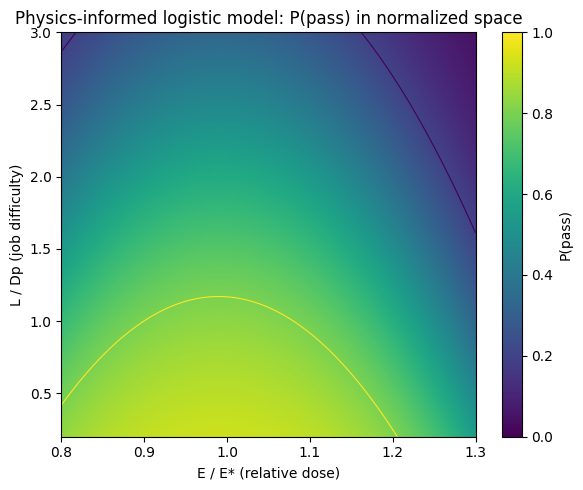

In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. Example resin table (replace with your real CSV)
# ---------------------------------------------------------
df_resins = pd.DataFrame({
    "resin_or_source": ["ExampleResin_A", "ExampleResin_B", "ExampleResin_C"],
    "Ec_mJcm2": [5.0, 4.0, 8.0],
    "Dp_um": [100.0, 80.0, 120.0],
})

# ---------------------------------------------------------
# 1. Physics planner
# ---------------------------------------------------------
def plan_exposures(
    df_resins,
    L_um=50.0,
    I_mWcm2=5.0,
    safety_factor=1.0,
    temperature_C=25.0,
    alpha_global=-0.0143,
):
    """
    Given Ec/Dp and job conditions, compute recommended E* and t* per resin.
    Uses Jacobs + global temp coefficient, then sorts by t*.
    """
    df = df_resins.copy()

    dT = temperature_C - 25.0
    scale_T = 1.0 + alpha_global * dT

    # Jacobs: Cd = Dp * ln(E / Ec), solve E for Cd = L_um
    df["E_star_mJcm2"] = df["Ec_mJcm2"] * np.exp(L_um / df["Dp_um"])

    # Safety factor + temperature adjustment
    df["E_star_mJcm2"] *= safety_factor * scale_T

    # Convert to time: (mJ/cm²) / (mW/cm²) = s
    df["t_star_s"] = df["E_star_mJcm2"] / I_mWcm2

    return df.sort_values("t_star_s").reset_index(drop=True)

# ---------------------------------------------------------
# 2. Synthetic experiments
# ---------------------------------------------------------
def simulate_experiments(
    df_resins,
    L_list_um=(50.0, 100.0, 150.0),
    I_mWcm2=5.0,
    safety_factor=1.0,
    temperature_C=25.0,
    alpha_global=-0.0143,
    dose_range=(0.8, 1.3),
    n_doses=9,
    reps_per_condition=10,
    rng_seed=42,
):
    """
    For each resin and thickness:
      1) Get E* from planner
      2) Sweep E/E* across dose_range
      3) For each (resin, L, E/E*) do multiple binomial draws
         from a physics-shaped p_pass.

    Design of p_pass:
      - Peak at E/E* = 1
      - Falls off as (E/E* - 1)^2
      - Harder jobs (high L/Dp) less forgiving
    """
    rng = np.random.default_rng(rng_seed)
    rows = []

    for L_um in L_list_um:
        planner = plan_exposures(
            df_resins,
            L_um=L_um,
            I_mWcm2=I_mWcm2,
            safety_factor=safety_factor,
            temperature_C=temperature_C,
            alpha_global=alpha_global,
        )

        for _, r in planner.iterrows():
            resin = r["resin_or_source"]
            Ec = r["Ec_mJcm2"]
            Dp = r["Dp_um"]
            E_star = r["E_star_mJcm2"]

            L_over_Dp = L_um / Dp

            for E_over in np.linspace(dose_range[0], dose_range[1], n_doses):
                E_trial = E_over * E_star

                # Symmetric peak at 1.0
                base = np.exp(-10.0 * (E_over - 1.0) ** 2)

                # Penalize harder jobs (L/Dp > 1)
                if L_over_Dp <= 1.0:
                    hardness = 1.0
                else:
                    hardness = np.exp(-0.8 * (L_over_Dp - 1.0))

                p_pass = base * hardness

                # Clamp to keep both classes present
                p_pass = float(np.clip(p_pass, 0.01, 0.99))

                # Multiple draws per condition to stabilize fit
                for _ in range(reps_per_condition):
                    y = rng.binomial(1, p_pass)
                    rows.append(dict(
                        resin_or_source=resin,
                        Ec_mJcm2=Ec,
                        Dp_um=Dp,
                        L_um=L_um,
                        E_star_mJcm2=E_star,
                        E_trial_mJcm2=E_trial,
                        E_over_Estar=E_over,
                        L_over_Dp=L_over_Dp,
                        p_pass_true=p_pass,
                        pass_fail=y,
                    ))

    return pd.DataFrame(rows)

dose_range = (0.8, 1.3)
df_exp = simulate_experiments(df_resins, dose_range=dose_range)

# ---------------------------------------------------------
# 3. Build ML table & train logistic regression
# ---------------------------------------------------------
X = pd.DataFrame({
    "E_over_Estar": df_exp["E_over_Estar"],
    "E_over_Estar_sq": df_exp["E_over_Estar"] ** 2,
    "L_over_Dp": df_exp["L_over_Dp"],
})
y = df_exp["pass_fail"].astype(int)

# Important: high C => weak regularization so it can learn the peak ~1.0
clf = LogisticRegression(max_iter=10000, C=1000.0)
clf.fit(X, y)

# ---------------------------------------------------------
# 4. 2D probability map (use the SAME range as training!)
# ---------------------------------------------------------
E_min, E_max = dose_range  # (0.8, 1.3)
Lrel_min, Lrel_max = 0.2, 3.0

E_grid = np.linspace(E_min, E_max, 200)
Lrel_grid = np.linspace(Lrel_min, Lrel_max, 200)
EE, LL = np.meshgrid(E_grid, Lrel_grid)

grid_features = pd.DataFrame({
    "E_over_Estar": EE.ravel(),
    "E_over_Estar_sq": (EE ** 2).ravel(),
    "L_over_Dp": LL.ravel(),
})

probs = clf.predict_proba(grid_features)
Z = probs[:, 1].reshape(EE.shape)  # column 1 = P(pass)

# ---------------------------------------------------------
# 5. Plot heatmap
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
hm = plt.imshow(
    Z,
    origin="lower",
    extent=[E_min, E_max, Lrel_min, Lrel_max],
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)
plt.colorbar(hm, label="P(pass)")
plt.contour(
    EE, LL, Z,
    levels=[0.2, 0.5, 0.8],
    linewidths=0.8,
)
plt.xlabel("E / E* (relative dose)")
plt.ylabel("L / Dp (job difficulty)")
plt.title("Physics-informed logistic model: P(pass) in normalized space")
plt.tight_layout()
plt.show()
